# Machine Learning Pipeline Demo

## Objective

This notebook demonstrates an end-to-end machine learning workflow using the Adult Census Income dataset.

The workflow includes:

- Loading the feature-engineered dataset
- Separating features and target variable
- Applying preprocessing pipelines
- Training a machine learning model
- Evaluating model performance
- Saving the complete pipeline for future predictions

A pipeline ensures that all preprocessing steps are automatically applied in the correct order during training and prediction.

In [31]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import joblib

import sys
import os

## Load Feature Engineered Dataset

The dataset used in this notebook is the final processed dataset created in:

`05_feature_engineering.ipynb`

It contains:

- Original cleaned features
- Engineered features
- Ready-to-use data for machine learning

In [32]:
df = pd.read_csv(
    "../datasets/adult/adult_feature_engineered.csv"
)

In [39]:
# Separate features and target

X = df.drop(
    "income",
    axis=1
)

y = df["income"]


print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (32537, 19)
Target Shape: (32537,)


## Separate Features and Target

The target variable in the Adult Census Income dataset is:

`income`

The objective is to train a machine learning model that predicts whether an individual's income is:

- `<=50K`
- `>50K`

All remaining columns will be used as input features.

## Feature Type Identification

Machine learning models require numerical inputs.

Therefore:

- Numerical features → Scaling
- Categorical features → One-Hot Encoding

The column groups are detected automatically.

In [40]:
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()


categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()


print("Numerical Features:")
print(numerical_features)


print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week', 'CapitalNet', 'IncomePerHour']

Categorical Features:
['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country', 'AgeGroup', 'WorkHoursCategory', 'EducationLevel']


C:\Users\abuba\AppData\Local\Temp\ipykernel_13616\1936885774.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


## Train-Test Split

The dataset is divided into:

- Training set (80%)
    - Used for learning patterns

- Testing set (20%)
    - Used for final evaluation

Stratification keeps the income class distribution balanced.

In [41]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (26029, 19)
Testing Shape: (6508, 19)


In [42]:
from src.pipeline import create_ml_pipeline


model_pipeline = create_ml_pipeline(
    numerical_features,
    categorical_features
)


model_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, def

## Train Machine Learning Pipeline

The complete pipeline is trained using the training dataset.

During training:

1. Numerical features are:
   - Missing values handled
   - Scaled using StandardScaler

2. Categorical features are:
   - Missing values handled
   - Converted using OneHotEncoder

3. The processed data is passed to the Logistic Regression model.

All preprocessing and model training happen together.

In [43]:
model_pipeline.fit(
    X_train,
    y_train
)


print("Pipeline training completed successfully!")

Pipeline training completed successfully!


## Generate Predictions

The trained pipeline is used on unseen test data.

The same preprocessing steps are automatically applied before prediction.

In [44]:
y_pred = model_pipeline.predict(
    X_test
)


y_pred[:10]

array(['<=50K', '>50K', '<=50K', '<=50K', '<=50K', '<=50K', '<=50K',
       '<=50K', '<=50K', '<=50K'], dtype=object)

## Check Prediction Distribution

In [45]:
prediction_counts = pd.Series(
    y_pred
).value_counts()


prediction_counts

<=50K    5188
>50K     1320
Name: count, dtype: int64

## Model Evaluation

The model performance is evaluated using:

1. Accuracy
2. Precision
3. Recall
4. F1-score
5. Confusion Matrix

These metrics help measure how well the model predicts income classes.

In [46]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [47]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.8598647818070068


In [48]:
report = classification_report(
    y_test,
    y_pred
)

print(report)

              precision    recall  f1-score   support

       <=50K       0.89      0.93      0.91      4940
        >50K       0.75      0.63      0.68      1568

    accuracy                           0.86      6508
   macro avg       0.82      0.78      0.80      6508
weighted avg       0.85      0.86      0.86      6508



In [49]:
cm = confusion_matrix(
    y_test,
    y_pred
)

cm

array([[4608,  332],
       [ 580,  988]])

## ROC-AUC Evaluation

ROC-AUC measures how well the model separates the two classes.

Unlike accuracy, ROC-AUC evaluates the model's confidence scores and is useful for binary classification.

Higher AUC indicates better class separation.

In [50]:
from sklearn.preprocessing import LabelEncoder


label_encoder = LabelEncoder()


y_test_encoded = label_encoder.fit_transform(
    y_test
)

y_test_encoded[:10]

array([0, 1, 0, 0, 0, 0, 0, 0, 0, 1])

In [51]:
y_prob = model_pipeline.predict_proba(
    X_test
)[:,1]


y_prob[:10]

array([0.04028681, 0.69420851, 0.02753835, 0.13481865, 0.04040595,
       0.03854334, 0.23074329, 0.03731655, 0.00094473, 0.31710833])

## Calculate ROC-AUC

In [52]:
from sklearn.metrics import roc_auc_score


roc_auc = roc_auc_score(
    y_test_encoded,
    y_prob
)


print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.9151943216557876


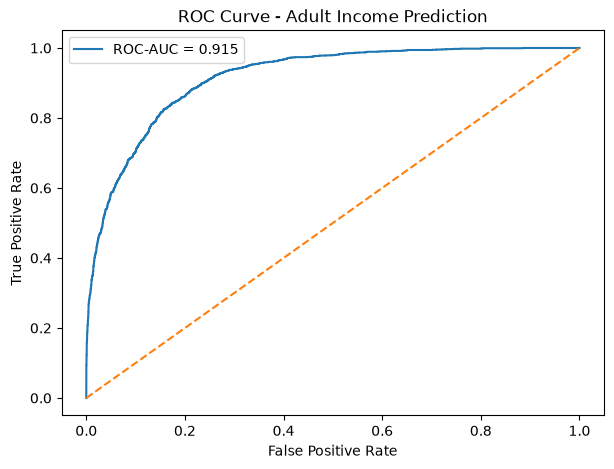

In [53]:
# Plot ROC Curve
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve


fpr, tpr, thresholds = roc_curve(
    y_test_encoded,
    y_prob
)


plt.figure(figsize=(7,5))


plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {roc_auc:.3f}"
)


plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)


plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve - Adult Income Prediction"
)

plt.legend()

plt.show()

## Save Evaluation Results

In [54]:
evaluation_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "ROC-AUC"
    ],
    "Score": [
        accuracy,
        roc_auc
    ]
})


evaluation_results

,Metric,Score
0,Accuracy,0.859865
1,ROC-AUC,0.915194


In [55]:
evaluation_results.to_csv(
    "../reports/model_evaluation.csv",
    index=False
)


print("Evaluation report saved!")

Evaluation report saved!



An ROC-AUC score of 0.915 indicates excellent class separation ability.

This means the model has a high probability of correctly ranking a randomly selected:

- Positive sample (`>50K income`)
- Negative sample (`<=50K income`)

The model successfully distinguishes between the two income categories with strong predictive capability.

## Save Trained Machine Learning Pipeline

The complete pipeline contains:

- Data preprocessing
    - Missing value handling
    - Numerical scaling
    - Categorical encoding

- Trained Logistic Regression model

Saving the pipeline allows future predictions without retraining the model.

In [56]:
import joblib


model_path = "../models/adult_income_pipeline.pkl"


joblib.dump(
    model_pipeline,
    model_path
)


print("Model saved successfully!")
print(model_path)

Model saved successfully!
../models/adult_income_pipeline.pkl


In [57]:
loaded_pipeline = joblib.load(
    "../models/adult_income_pipeline.pkl"
)


print(type(loaded_pipeline))

<class 'sklearn.pipeline.Pipeline'>


In [58]:
loaded_predictions = loaded_pipeline.predict(
    X_test
)


loaded_predictions[:10]

array(['<=50K', '>50K', '<=50K', '<=50K', '<=50K', '<=50K', '<=50K',
       '<=50K', '<=50K', '<=50K'], dtype=object)

In [59]:
print(
    np.array_equal(
        y_pred,
        loaded_predictions
    )
)

True


In [60]:
#final model report
final_report = pd.DataFrame({
    "Model": [
        "Logistic Regression Pipeline"
    ],
    "Accuracy": [
        accuracy
    ],
    "ROC-AUC": [
        roc_auc
    ],
    "Training Samples": [
        X_train.shape[0]
    ],
    "Testing Samples": [
        X_test.shape[0]
    ],
    "Features Used": [
        X.shape[1]
    ]
})


final_report

,Model,Accuracy,ROC-AUC,Training Samples,Testing Samples,Features Used
0,Logistic Regression Pipeline,0.859865,0.915194,26029,6508,19


In [61]:
final_report.to_csv(
    "../reports/final_model_report.csv",
    index=False
)


print("Final model report saved!")

Final model report saved!


In [62]:
cm

array([[4608,  332],
       [ 580,  988]])

<Figure size 600x500 with 0 Axes>

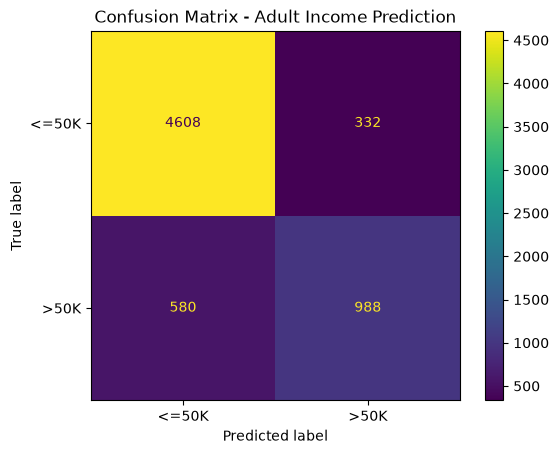

In [63]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay


plt.figure(figsize=(6,5))


display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "<=50K",
        ">50K"
    ]
)


display.plot()


plt.title(
    "Confusion Matrix - Adult Income Prediction"
)


plt.savefig(
    "../reports/confusion_matrix.png",
    bbox_inches="tight"
)


plt.show()

## Save ROC Curve Image

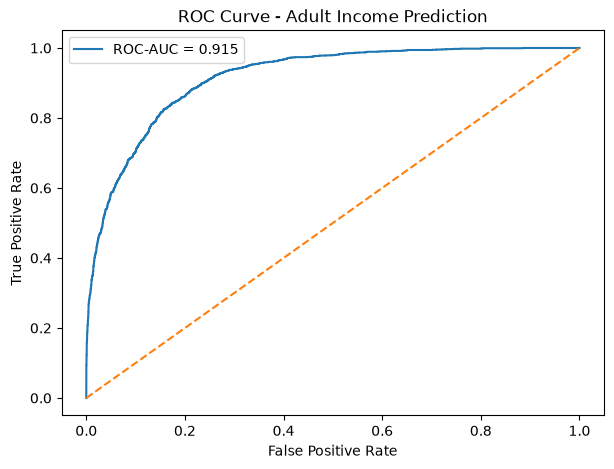

In [64]:
plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {roc_auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve - Adult Income Prediction"
)

plt.legend()


plt.savefig(
    "../reports/roc_curve.png",
    bbox_inches="tight"
)


plt.show()